# Data Preparation — Churn Prediction

In [1]:
import pandas as pd
from transformer import BinaryEncoder, FrequencyEncoder, OrdinalExtensionEncoder, OrdinalEquipamientoEncoder, NominalOneHotEncoder, PriceStandard, InstanceDropper, ColumnDropper
from sklearn.pipeline import Pipeline

In [2]:
customer_data = pd.read_csv("data/lake/customer_data.csv")

In [3]:
customer_data[['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']] = (
    customer_data[['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']]
        .apply(pd.to_datetime, errors='coerce', dayfirst=True, format='%d/%m/%Y')
    )

In [4]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(customer_data, test_size=0.2, random_state=42)

In [5]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 46439 entries, 32588 to 56422
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   CODE                          46439 non-null  str           
 1   Sales_Date                    46439 non-null  datetime64[us]
 2   Id_Producto                   46439 non-null  str           
 3   Customer_ID                   46439 non-null  int64         
 4   PVP                           46439 non-null  int64         
 5   MOTIVO_VENTA                  46439 non-null  str           
 6   FORMA_PAGO                    46439 non-null  str           
 7   EXTENSION_GARANTIA            46439 non-null  str           
 8   SEGURO_BATERIA_LARGO_PLAZO    46439 non-null  str           
 9   MANTENIMIENTO_GRATUITO        46439 non-null  int64         
 10  FIN_GARANTIA                  46439 non-null  datetime64[us]
 11  BASE_DATE                     46439 non-

In [6]:
test_set.to_csv("data/warehouse/test_set.csv", index=False)

## Transformar todas las variables dicotómicas a numéricas, utilizando One-Hot Encoding para las variables categóricas

In [7]:
full_pipeline = Pipeline([
    ('binary',              BinaryEncoder()),
    ('frequency',           FrequencyEncoder()),
    ('ordinal_ext',         OrdinalExtensionEncoder()),
    ('ordinal_equip',       OrdinalEquipamientoEncoder()),
    ('onehot',              NominalOneHotEncoder()),
    ('price_standard',      PriceStandard()),
    ('instance_dropper',    InstanceDropper()),
    ('dropper',             ColumnDropper()),
])

In [8]:
train_set_prepared = full_pipeline.fit_transform(train_set)
print("Shape final:", train_set_prepared.shape)

Shape final: (35982, 36)


In [9]:
train_set_prepared.info()

<class 'pandas.DataFrame'>
Index: 35982 entries, 8920 to 56422
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PVP                           35982 non-null  float64
 1   EXTENSION_GARANTIA            35982 non-null  float64
 2   SEGURO_BATERIA_LARGO_PLAZO    35982 non-null  int64  
 3   MANTENIMIENTO_GRATUITO        35982 non-null  float64
 4   EN_GARANTIA                   35982 non-null  int64  
 5   Edad                          35982 non-null  int64  
 6   RENTA_MEDIA_ESTIMADA          35982 non-null  int64  
 7   Modelo                        35982 non-null  float64
 8   Equipamiento                  35982 non-null  float64
 9   Kw                            35982 non-null  int64  
 10  Revisiones                    35982 non-null  int64  
 11  QUEJA                         35982 non-null  int64  
 12  Lead_compra                   35982 non-null  int64  
 13  Fue_Lead      

array([[<Axes: title={'center': 'PVP'}>,
        <Axes: title={'center': 'EXTENSION_GARANTIA'}>,
        <Axes: title={'center': 'SEGURO_BATERIA_LARGO_PLAZO'}>,
        <Axes: title={'center': 'MANTENIMIENTO_GRATUITO'}>,
        <Axes: title={'center': 'EN_GARANTIA'}>,
        <Axes: title={'center': 'Edad'}>],
       [<Axes: title={'center': 'RENTA_MEDIA_ESTIMADA'}>,
        <Axes: title={'center': 'Modelo'}>,
        <Axes: title={'center': 'Equipamiento'}>,
        <Axes: title={'center': 'Kw'}>,
        <Axes: title={'center': 'Revisiones'}>,
        <Axes: title={'center': 'QUEJA'}>],
       [<Axes: title={'center': 'Lead_compra'}>,
        <Axes: title={'center': 'Fue_Lead'}>,
        <Axes: title={'center': 'PROV_DESC'}>,
        <Axes: title={'center': 'Churn_400'}>,
        <Axes: title={'center': 'MOTIVO_VENTA_No Particular'}>,
        <Axes: title={'center': 'MOTIVO_VENTA_Particular'}>],
       [<Axes: title={'center': 'Fuel_ELÉCTRICO'}>,
        <Axes: title={'center': 'Fue

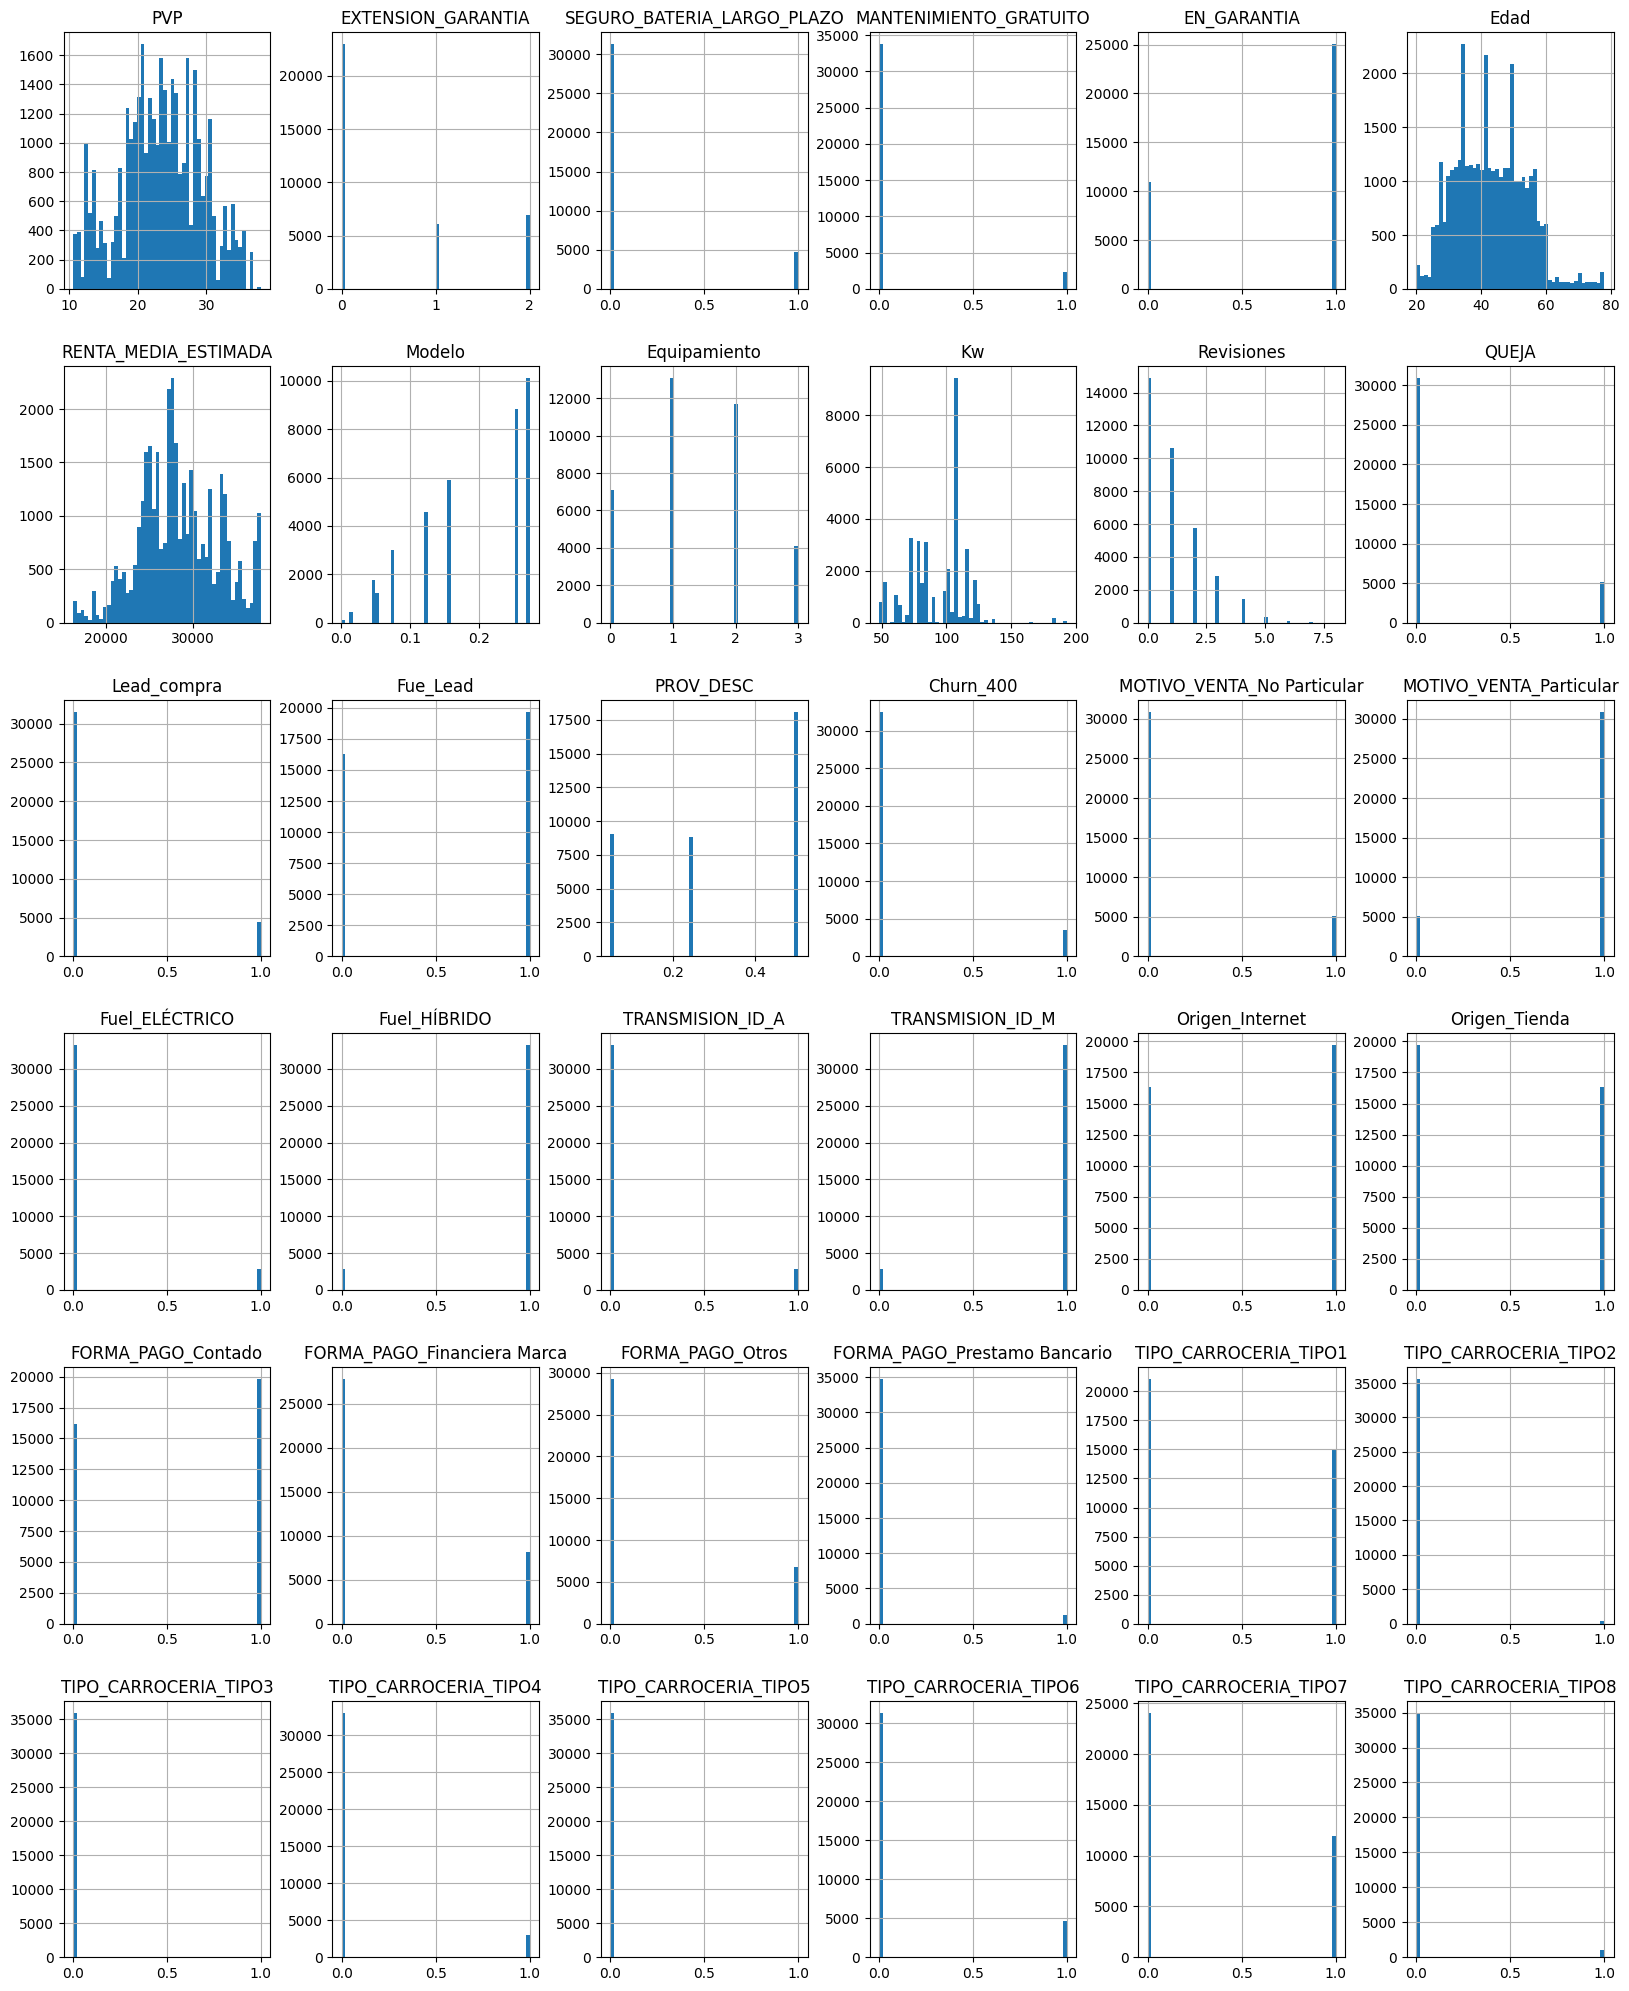

In [10]:
train_set_prepared.hist(bins=50, figsize=(20, 25))

In [11]:
import joblib

X_train_prepared = train_set_prepared.drop(columns=['Churn_400'])
y_train = train_set_prepared['Churn_400']

joblib.dump(full_pipeline, 'data/warehouse/num_pipeline.pkl')
joblib.dump(X_train_prepared, 'data/warehouse/X_train_prepared.pkl')
joblib.dump(y_train, 'data/warehouse/y_train.pkl')

print("Pipeline y datos guardados ✓")

Pipeline y datos guardados ✓
